## Llamado al archivo de configuracion principal

In [2]:
# Ejecutar configuración
%run 00_setup.ipynb

# Consulta
query = "SELECT * FROM regeventos"

df = pd.read_sql(query, engine)

df.head()


✅ Configuración cargada correctamente
📊 Conectado a: coniiti.com/coniitic_registro


,id,qr_Acceso,nombres,apellidos,email,telefono,tipo_documento,num_documento,genero,pais,ucatolica,rol,programa,profesion,nom_Evento,qr_validado,fecha_uso,fecha_registro
0,4,OXL3IHNL6KFN8KGPQE,yenny,hernandez,jphernandez@ucatolica.edu.co,3168232187,CC,1024486270,Femenino,Colombia,S,Administrativo,Facultad de Ingeniería,Adminsitradora financiera,Del reto a la solución: Innovar con Design Thi...,1,2025-10-01 15:05:30,2025-09-30 13:58:57
1,5,5RBN17AAE2OOL47485,Diego Fernando,Meléndez Suárez,dfmelendez@ucatolica.edu.co,3183530817,CC,91284150,Masculino,Colombia,S,Profesor/Administrativo,Esp. en Ingeniería de Pavimentos,Ingeniero Civil,Workshop: Diseños de mezcla de concreto bajo l...,0,NaT,2025-09-30 18:15:53
2,6,R2SV7WXIAQ63Y1GIL3,Diego Fernando,Meléndez Suárez,dfmelendez@ucatolica.edu.co,3183530817,CC,91284150,Masculino,Colombia,S,Profesor/Administrativo,Esp. en Ingeniería de Pavimentos,Ingeniero Civil,Conferencia : Arquitectura y diseño sostenible...,0,NaT,2025-09-30 18:31:52
3,7,P58X4OTXBNFUAQIJ54,Diego Fernando,Meléndez Suárez,dfmelendez@ucatolica.edu.co,3183530817,CC,91284150,Masculino,Colombia,S,Profesor/Administrativo,Esp. en Ingeniería de Pavimentos,Ingeniero Civil,Conferencia: Proyectos comprometidos con la so...,0,NaT,2025-09-30 18:32:43
4,8,MK8DW21CHVHXTGBAS5,Oscar Raul,Pinto Celis,orpinto@ucatolica.edu.co,3125812914,CC,91500261,Masculino,Colombia,S,Profesor/Administrativo,Esp. en Gerencia de Obras,Ingeniero Civil,Conferencia: Premio Nacional de Ingeniería: Re...,1,2025-10-02 14:05:02,2025-09-30 18:32:53


## creamos una grafica usando los campos de nombre_Evento para comparar inscritos vs asistentes y su tasa promedios

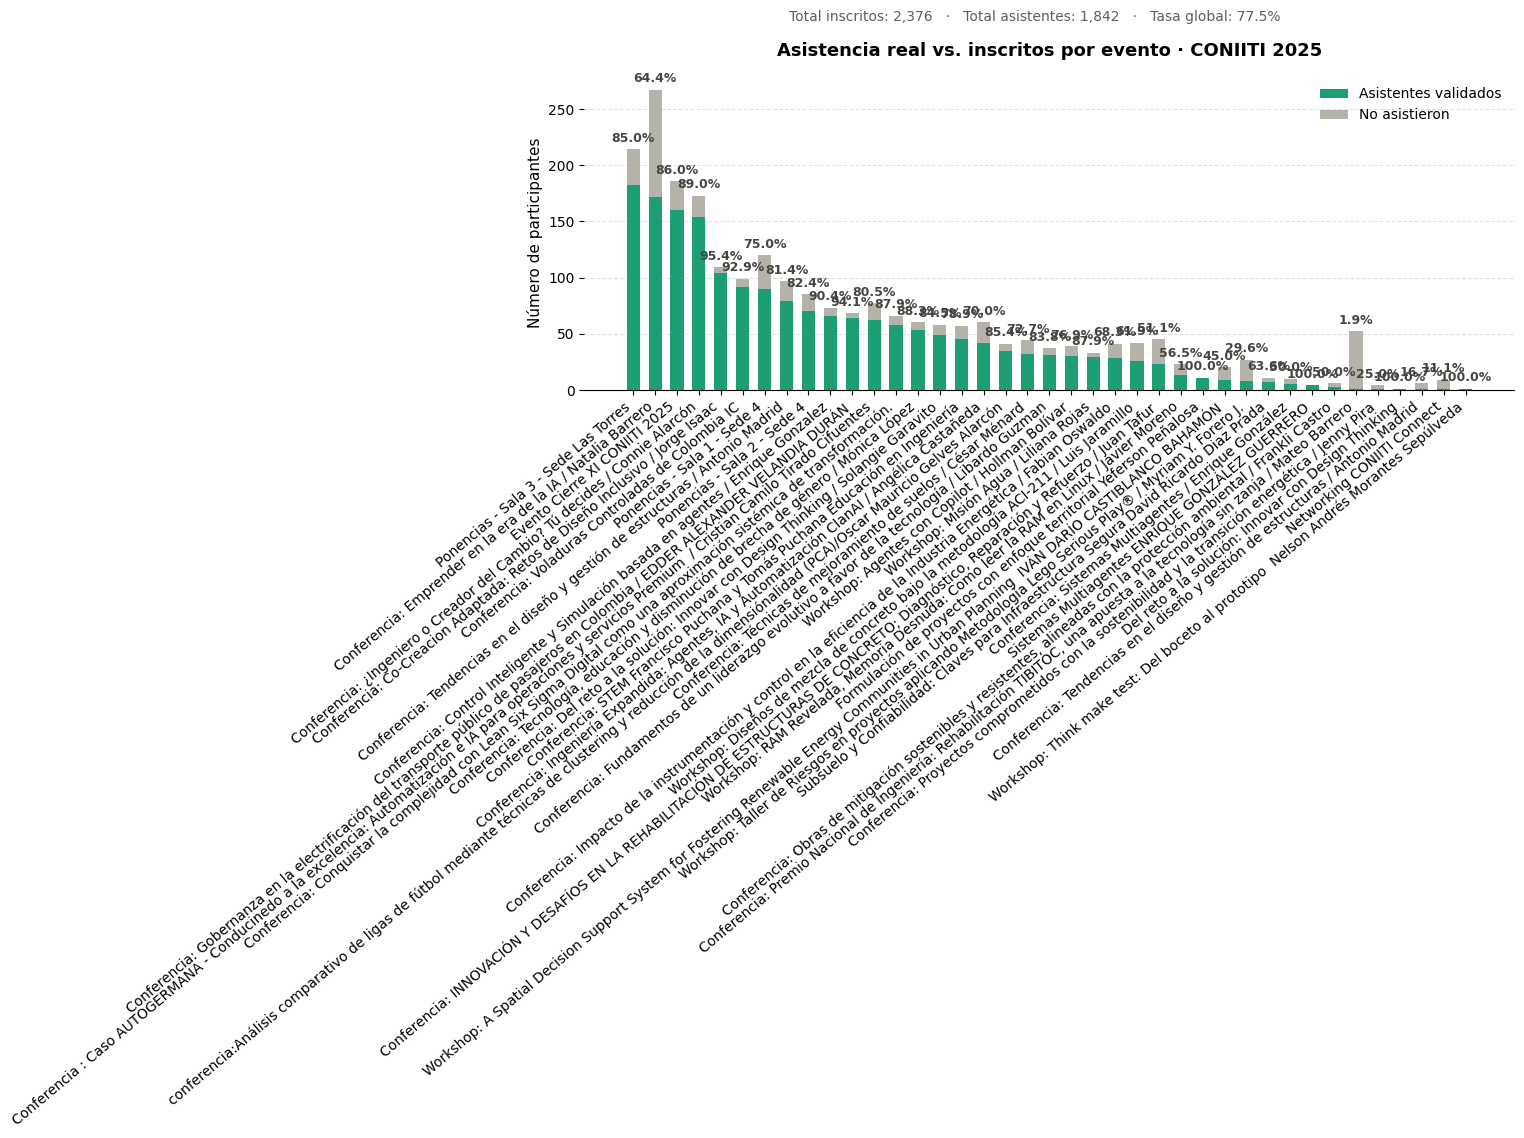

In [6]:

# ── datos ────────────────────────────────────────────────────────
# inscritos_evento   → total de registros por evento

inscritos_evento = df.groupby("nom_Evento")["id"].count()
asistencia_evento = df[df["qr_validado"] == 1].groupby("nom_Evento")["id"].count()

# Ordenar de mayor a menor asistencia
orden = asistencia_evento.sort_values(ascending=False).index
asistentes = asistencia_evento.reindex(orden).fillna(0)
inscritos   = inscritos_evento.reindex(orden).fillna(0)
no_asistieron = inscritos - asistentes
tasas = (asistentes / inscritos * 100).round(1)

# ── figura ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(orden))
ancho = 0.6

barras_asistentes   = ax.bar(x, asistentes,   ancho, label="Asistentes validados", color="#1D9E75", zorder=2)
barras_no_asistieron = ax.bar(x, no_asistieron, ancho, bottom=asistentes,
                               label="No asistieron", color="#B4B2A9", zorder=2)

# Etiqueta de tasa sobre cada barra
for i, (h, t) in enumerate(zip(inscritos, tasas)):
    ax.text(i, h + inscritos.max() * 0.015, f"{t}%",
            ha="center", va="bottom", fontsize=9, color="#444441", fontweight="bold")

# Estética
ax.set_xticks(x)
ax.set_xticklabels(orden, rotation=40, ha="right", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_ylabel("Número de participantes", fontsize=11)
ax.set_title("Asistencia real vs. inscritos por evento · CONIITI 2025",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.spines[["top","right","left"]].set_visible(False)

# Métricas resumen en el subtítulo
total_i = int(inscritos.sum())
total_a = int(asistentes.sum())
tasa_gral = round(total_a / total_i * 100, 1)
fig.suptitle(
    f"Total inscritos: {total_i:,}   ·   Total asistentes: {total_a:,}   ·   Tasa global: {tasa_gral}%",
    fontsize=10, color="#5F5E5A", y=1.01
)

plt.subplots_adjust(top=0.88, bottom=0.25)
plt.savefig("asistencia_evento.png", dpi=150, bbox_inches="tight")
plt.show()

## Una mejora del Gráfico anterior usando interactividad al pasar el cursor (Usando)

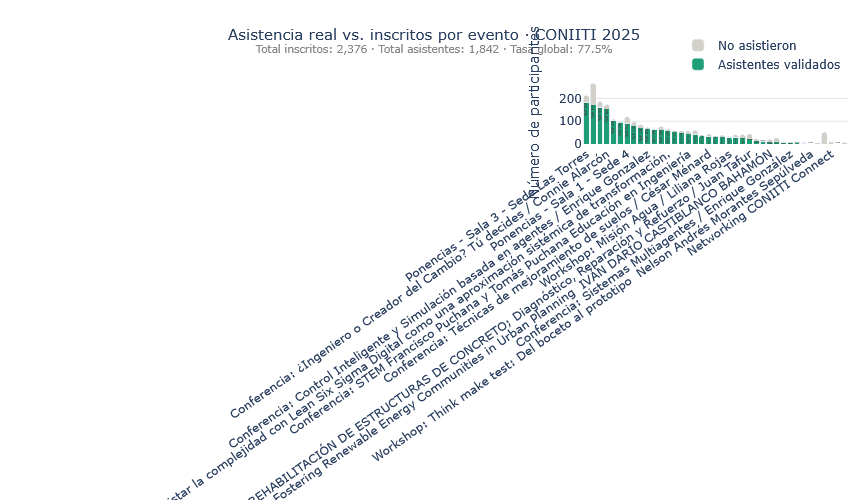

In [16]:
# ── datos ────────────────────────────────────────────────────────
orden = asistencia_evento.sort_values(ascending=False).index
asistentes   = asistencia_evento.reindex(orden).fillna(0).astype(int)
inscritos    = inscritos_evento.reindex(orden).fillna(0).astype(int)
no_asistieron = inscritos - asistentes
tasas        = (asistentes / inscritos * 100).round(1)

total_i   = int(inscritos.sum())
total_a   = int(asistentes.sum())
tasa_gral = round(total_a / total_i * 100, 1)

# ── figura ───────────────────────────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Bar(
    name="Asistentes validados",
    x=list(orden),
    y=list(asistentes),
    marker=dict(
        color="#1D9E75",
        cornerradius=4,
    ),
    text=[f"{t}%" for t in tasas],
    textposition="outside",
    textfont=dict(size=11, color="#444441"),
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Asistentes: %{y:,}<br>"
        "Tasa: %{text}<extra></extra>"
    ),
))

fig.add_trace(go.Bar(
    name="No asistieron",
    x=list(orden),
    y=list(no_asistieron),
    marker=dict(
        color="#D3D1C7",
        cornerradius=4,
    ),    
    hovertemplate=(
        "<b>%{x}</b><br>"
        "No asistieron: %{y:,}<extra></extra>"
    ),
))

fig.update_layout(
    barmode="stack",
    title=dict(
        text=(
            f"Asistencia real vs. inscritos por evento · CONIITI 2025"
            f"<br><sup style='color:#888'>Total inscritos: {total_i:,} · "
            f"Total asistentes: {total_a:,} · Tasa global: {tasa_gral}%</sup>"
        ),
        font=dict(size=15),
        x=0.5,
        xanchor="center",
    ),
    xaxis=dict(
        tickangle=-35,
        showgrid=False,
        showline=False,
    ),
    yaxis=dict(
        title="Número de participantes",
        gridcolor="rgba(136,135,128,0.2)",
        showline=False,
        zeroline=False,
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
        bgcolor="rgba(0,0,0,0)",
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=100, b=120, l=60, r=20),
    height=500,
)

fig.show()

# Exportar imagen estática (requiere kaleido: pip install kaleido)
# fig.write_image("asistencia_evento.png", scale=2)

In [1]:
import plotly
print(plotly.__version__)  # corner_radius disponible desde 5.19.0

6.5.2


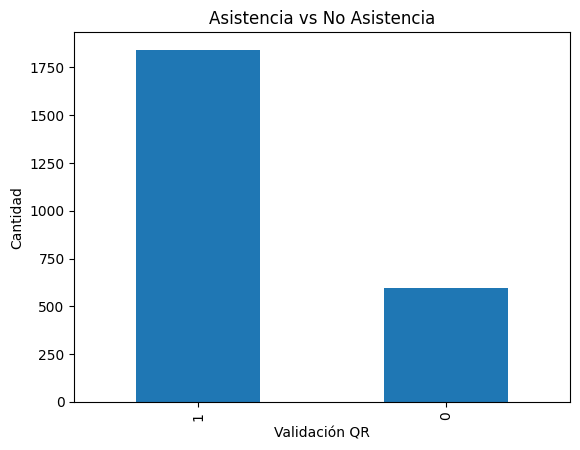

In [3]:
df['qr_validado'].value_counts().plot(kind='bar')
plt.title("Asistencia vs No Asistencia")
plt.xlabel("Validación QR")
plt.ylabel("Cantidad")
plt.show()

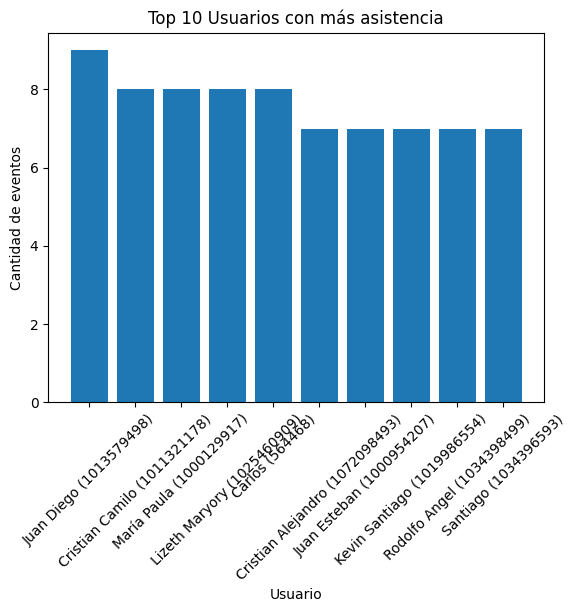

In [9]:
# Agrupar por usuario
top_users = df.groupby(['num_documento', 'nombres']).size().reset_index(name='cantidad')

# Ordenar y tomar top 10
top_users = top_users.sort_values(by='cantidad', ascending=False).head(10)

# Crear etiqueta combinada (Nombre + Documento opcional)
top_users['label'] = top_users['nombres'] + " (" + top_users['num_documento'].astype(str) + ")"

# Graficar
plt.figure()
plt.bar(top_users['label'], top_users['cantidad'])
plt.title("Top 10 Usuarios con más asistencia")
plt.xlabel("Usuario")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=45)
plt.show()

In [7]:
# Convertir fechas
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])
df['fecha_uso'] = pd.to_datetime(df['fecha_uso'])

# Variable objetivo
df['asistio'] = df['qr_validado']

In [9]:
df['dias_anticipacion'] = (
    df['fecha_uso'] - df['fecha_registro']
).dt.days

In [10]:
eventos_por_persona = df.groupby('num_documento')['nom_Evento'].count()

df = df.merge(
    eventos_por_persona.rename('total_eventos_persona'),
    on='num_documento'
)

In [11]:
asistencias_persona = df[df['asistio'] == 1] \
    .groupby('num_documento')['nom_Evento'] \
    .count()

df = df.merge(
    asistencias_persona.rename('eventos_asistidos'),
    on='num_documento',
    how='left'
)

df['eventos_asistidos'] = df['eventos_asistidos'].fillna(0)

In [12]:
df['tasa_asistencia_persona'] = (
    df['eventos_asistidos'] / df['total_eventos_persona']
)

In [13]:
df['tasa_asistencia_persona'] = (
    df['eventos_asistidos'] / df['total_eventos_persona']
)

In [14]:
df_personas = df.groupby('num_documento').agg({
    'nom_Evento': 'count',
    'asistio': 'sum'
}).rename(columns={
    'nom_Evento': 'total_eventos',
    'asistio': 'eventos_asistidos'
})

df_personas['multi_evento'] = df_personas['eventos_asistidos'] > 1

df_personas['multi_evento'].value_counts()

multi_evento
False    764
True     456
Name: count, dtype: int64

In [15]:
df['dias_anticipacion'].mean()

np.float64(0.020065075921908895)

In [16]:
df.groupby('asistio')['dias_anticipacion'].mean()

asistio
0    0.000000
1    0.020087
Name: dias_anticipacion, dtype: float64

In [18]:
df_personas['tasa_asistencia'] = (
    df_personas['eventos_asistidos'] / df_personas['total_eventos']
)

df_personas.groupby('multi_evento')['tasa_asistencia'].mean()

multi_evento
False    0.664114
True     0.885152
Name: tasa_asistencia, dtype: float64

In [19]:
df_personas['eventos_asistidos'].value_counts().sort_index()

eventos_asistidos
0    195
1    569
2    243
3    119
4     53
5     28
6     13
Name: count, dtype: int64

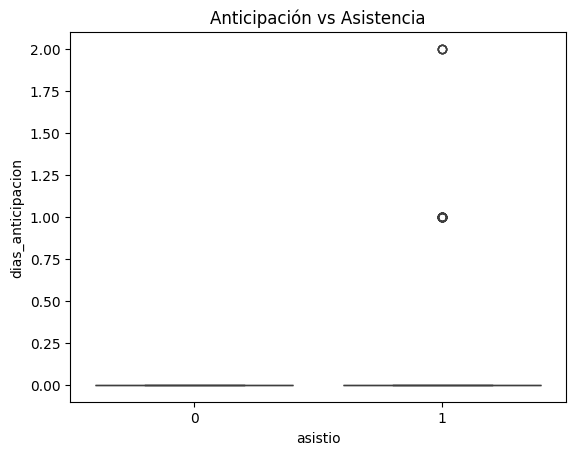

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df,
    x='asistio',
    y='dias_anticipacion'
)

plt.title("Anticipación vs Asistencia")
plt.show()

In [21]:
df_personas.sort_values(
    'eventos_asistidos',
    ascending=False
).head(10)

,total_eventos,eventos_asistidos,multi_evento,tasa_asistencia
num_documento,,,,
1014738863,6,6,True,1.000000
1000129917,10,6,True,0.600000
1006030429,6,6,True,1.000000
1034396593,7,6,True,0.857143
1011321178,8,6,True,0.750000
1118362718,7,6,True,0.857143
1025526601,6,6,True,1.000000
1023864142,6,6,True,1.000000
1034285981,6,6,True,1.000000
